# Spam Detection using Decision Trees

**Course:** CS1461 - Machine Learning  
**Instructor:** Dr. Abeer Alsheddi.

**Team Members:**
1. Reham Mobark Aldosari - 445001187
2. Nadeen Yahya Alameer - 445003959
3. Alya Ibraheem Almatroodi - 445003067
4. Aljori Aladaili - 443021118

---

## Step 1: Import Shared Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Step 2: Load the Dataset

In [2]:
feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_parenthesis', 'char_freq_bracket',
    'char_freq_exclamation', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'class_label'
]

df = pd.read_csv('spambase.data', header=None, names=feature_names)
print(f"Dataset loaded: {df.shape[0]} emails, {df.shape[1]-1} features")
df.head(3)

Dataset loaded: 4601 emails, 57 features


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class_label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1


## Step 3: Separate Features and Labels

In [3]:
# X = all 57 feature columns
X = df.drop('class_label', axis=1)

# y = the label column (1=spam, 0=not spam)
y = df['class_label']

print(f"Features (X): {X.shape}")
print(f"Labels   (y): {y.shape}")

Features (X): (4601, 57)
,Labels   (y): (4601,)


## Step 4: Split into Train / Validation / Test

We split the data into 3 parts:
- **Training (70%)** — the model learns from this
- **Validation (15%)** — used to tune the model
- **Test (15%)** — final evaluation only

We use `stratify=y` to keep the same spam ratio in all splits.

In [4]:
# 70% train, 30% (val+test)
X_train, X_valtest, y_train, y_valtest = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# split the 30% into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_valtest, y_valtest, test_size=0.50, random_state=42, stratify=y_valtest
)

print("___ Split Summary ___")
print(f"Train:      {len(X_train)} emails ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val)} emails ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test)} emails ({len(X_test)/len(X)*100:.0f}%)")

___ Split Summary ___
,Train:      3220 emails (70%)
,Validation: 690 emails (15%)
,Test:       691 emails (15%)


In [5]:
# verify spam ratio is consistent across splits
print("___ Spam Distribution ___")
print(f"Training:   {y_train.value_counts()[0]} Not Spam, {y_train.value_counts()[1]} Spam  ({y_train.mean()*100:.1f}% spam)")
print(f"Validation: {y_val.value_counts()[0]} Not Spam, {y_val.value_counts()[1]} Spam  ({y_val.mean()*100:.1f}% spam)")
print(f"Test:       {y_test.value_counts()[0]} Not Spam, {y_test.value_counts()[1]} Spam  ({y_test.mean()*100:.1f}% spam)")

___ Spam Distribution ___
,Training:   1951 Not Spam, 1269 Spam  (39.4% spam)
,Validation: 418 Not Spam, 272 Spam  (39.4% spam)
,Test:       419 Not Spam, 272 Spam  (39.4% spam)


---
## Base Model

We train a Decision Tree with no modifications — no normalization, no pruning, no balancing. This serves as our baseline for all comparisons.

Base Model Accuracy: 87.84%


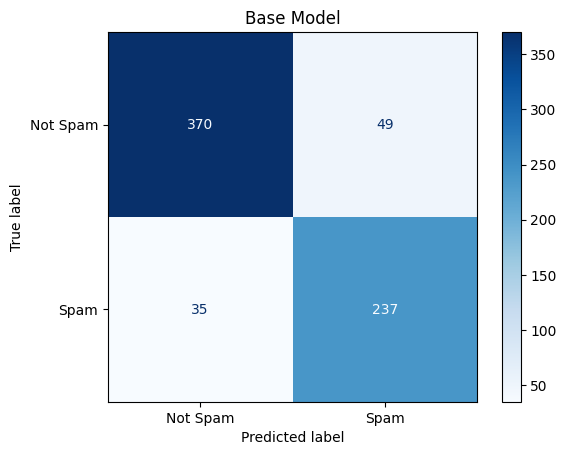

              precision    recall  f1-score   support
,
,    Not Spam       0.91      0.88      0.90       419
,        Spam       0.83      0.87      0.85       272
,
,    accuracy                           0.88       691
,   macro avg       0.87      0.88      0.87       691
,weighted avg       0.88      0.88      0.88       691
,


In [6]:
# train the base model
b_model = DecisionTreeClassifier(random_state=42)
b_model.fit(X_train, y_train)

# predict on test set
b_pred = b_model.predict(X_test)

# accuracy
b_acc = accuracy_score(y_test, b_pred)
print(f"Base Model Accuracy: {b_acc*100:.2f}%")

# confusion matrix
b_matrix = confusion_matrix(y_test, b_pred)
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(cmap='Blues')
plt.title('Base Model')
plt.show()

print(classification_report(y_test, b_pred, target_names=['Not Spam', 'Spam']))

---
---
# Case 1: Normalization (With vs Without)

Normalization rescales all features to a similar range. This is important because our features have very different scales — for example `word_freq_free` ranges from 0 to 5, while `capital_run_length_total` ranges from 1 to 15,000.

We test 3 different normalization methods:
- **MinMaxScaler** — rescales values to [0, 1]
- **StandardScaler** — rescales so mean=0 and standard deviation=1
- **RobustScaler** — uses median instead of mean, better with outliers

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

### 1.1 MinMaxScaler
Rescales all features to be between 0 and 1:

MinMaxScaler Accuracy: 87.84%


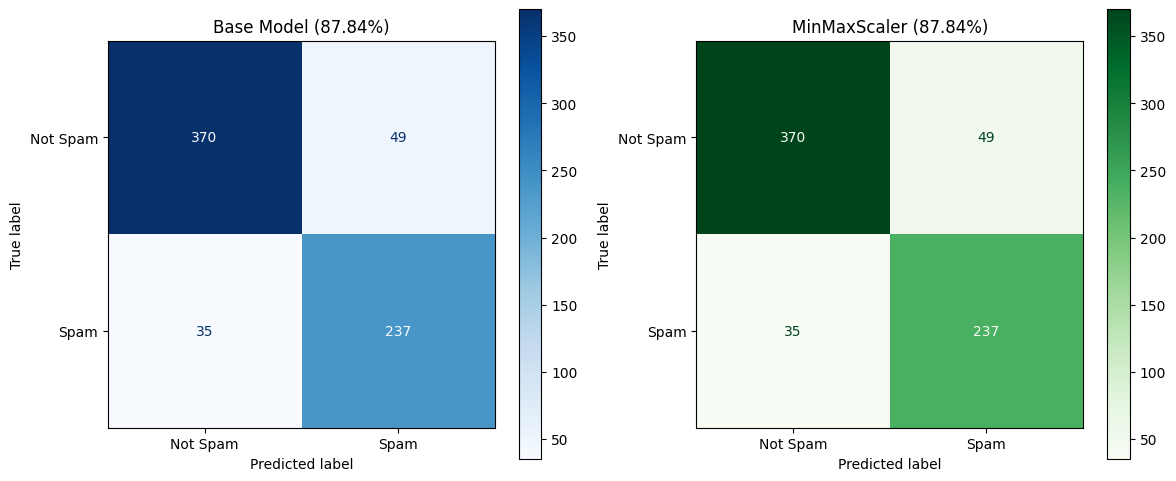

In [8]:
# apply MinMaxScaler - fit on training data only
minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm  = minmax.transform(X_test)

# train decision tree on MinMax normalized data
model_mm = DecisionTreeClassifier(random_state=42)
model_mm.fit(X_train_mm, y_train)
pred_mm = model_mm.predict(X_test_mm)
acc_mm = accuracy_score(y_test, pred_mm)
cm_mm = confusion_matrix(y_test, pred_mm)

print(f"MinMaxScaler Accuracy: {acc_mm*100:.2f}%")

# side by side: base vs MinMax
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Base Model ({b_acc*100:.2f}%)')
ConfusionMatrixDisplay(cm_mm, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'MinMaxScaler ({acc_mm*100:.2f}%)')
plt.tight_layout()
plt.show()

### 1.2 StandardScaler
Rescales features so the mean becomes 0 and standard deviation becomes 1:

StandardScaler Accuracy: 87.99%


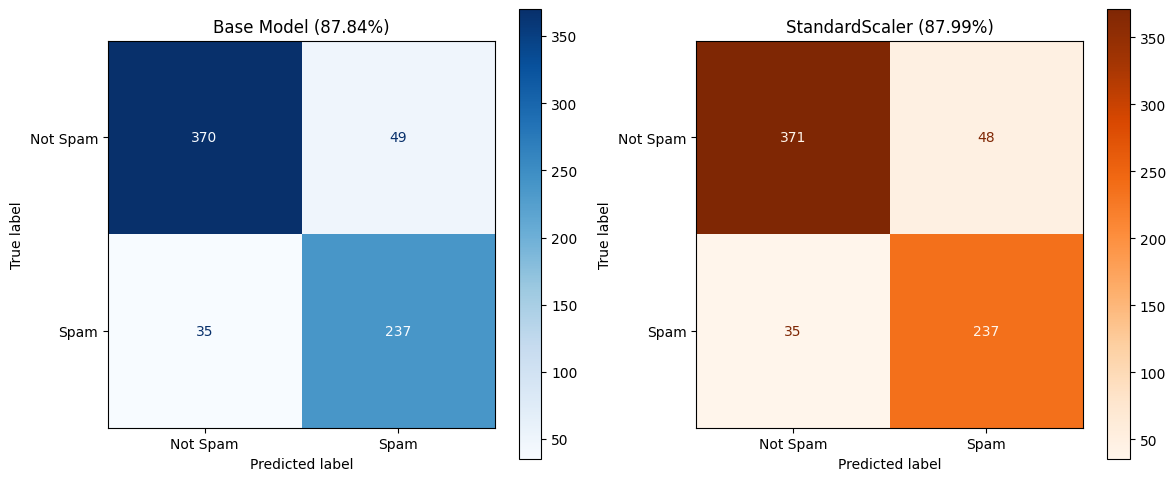

In [9]:
# apply StandardScaler - fit on training data only
standard = StandardScaler()
X_train_ss = standard.fit_transform(X_train)
X_test_ss  = standard.transform(X_test)

# train decision tree on Standard normalized data
model_ss = DecisionTreeClassifier(random_state=42)
model_ss.fit(X_train_ss, y_train)
pred_ss = model_ss.predict(X_test_ss)
acc_ss = accuracy_score(y_test, pred_ss)
cm_ss = confusion_matrix(y_test, pred_ss)

print(f"StandardScaler Accuracy: {acc_ss*100:.2f}%")

# side by side: base vs Standard
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Base Model ({b_acc*100:.2f}%)')
ConfusionMatrixDisplay(cm_ss, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title(f'StandardScaler ({acc_ss*100:.2f}%)')
plt.tight_layout()
plt.show()

### 1.3 RobustScaler
Uses the median and interquartile range instead of mean and standard deviation. More resistant to outliers.

RobustScaler Accuracy: 87.84%


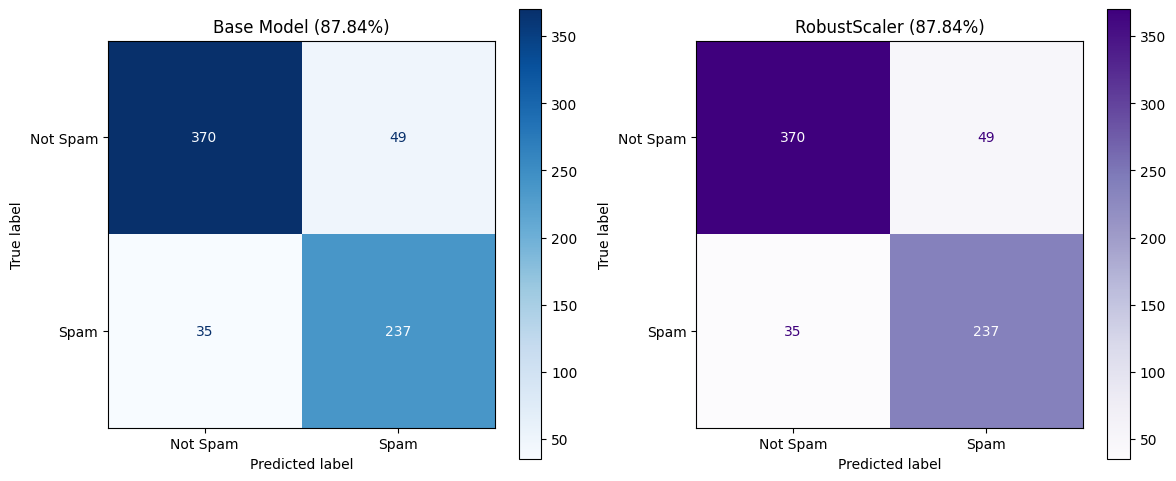

In [10]:
# apply RobustScaler - fit on training data only
robust = RobustScaler()
X_train_rb = robust.fit_transform(X_train)
X_test_rb  = robust.transform(X_test)

# train decision tree on Robust normalized data
model_rb = DecisionTreeClassifier(random_state=42)
model_rb.fit(X_train_rb, y_train)
pred_rb = model_rb.predict(X_test_rb)
acc_rb = accuracy_score(y_test, pred_rb)
cm_rb = confusion_matrix(y_test, pred_rb)

print(f"RobustScaler Accuracy: {acc_rb*100:.2f}%")

# side by side: base vs Robust
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Base Model ({b_acc*100:.2f}%)')
ConfusionMatrixDisplay(cm_rb, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Purples')
axes[1].set_title(f'RobustScaler ({acc_rb*100:.2f}%)')
plt.tight_layout()
plt.show()

### Normalization Summary

In [11]:
# summary table comparing all normalization methods
summary = pd.DataFrame({
    'Method': ['Base (No Normalization)', 'MinMaxScaler', 'StandardScaler', 'RobustScaler'],
    'Accuracy': [f'{b_acc*100:.2f}%', f'{acc_mm*100:.2f}%', f'{acc_ss*100:.2f}%', f'{acc_rb*100:.2f}%']
})
print("___ Normalization Comparison ___")
print(summary.to_string(index=False))

___ Normalization Comparison ___
,                 Method Accuracy
,Base (No Normalization)   87.84%
,           MinMaxScaler   87.84%
,         StandardScaler   87.99%
,           RobustScaler   87.84%


### Discussion

MinMaxScaler and RobustScaler produced identical results to the base model (87.84%).
StandardScaler showed a very slight improvement (87.99%), correctly classifying one
additional Not Spam email.

Overall, normalization has minimal impact on Decision Trees because they split data
based on thresholds (e.g. "is value > 0.5?"), not distances. Rescaling does not change
where the tree splits. The small difference in StandardScaler is likely due to minor
changes in how the tree handles floating point values after rescaling.

Normalization would have a much bigger impact on distance-based algorithms like KNN or
SVM, where features with larger ranges dominate the distance calculation.


---
# Case 2: Overfitting (With vs Without)


### 2.1 Show the overfitting occur

In [12]:
train_acc_base = accuracy_score(y_train, b_model.predict(X_train))
val_acc_base   = accuracy_score(y_val,   b_model.predict(X_val))
test_acc_base  = accuracy_score(y_test,  b_pred)
print(f"Training Accuracy:   {train_acc_base*100:.2f}%")
print(f"Test Accuracy:       {test_acc_base*100:.2f}%")
print(f"Tree Depth:          {b_model.get_depth()}")
print(f"Number of Leaves:    {b_model.get_n_leaves()}")

Training Accuracy:   99.97%
,Test Accuracy:       87.84%
,Tree Depth:          32
,Number of Leaves:    214


Overfitting has occurred

### 2.2 Plotting the training vs. validation score curves

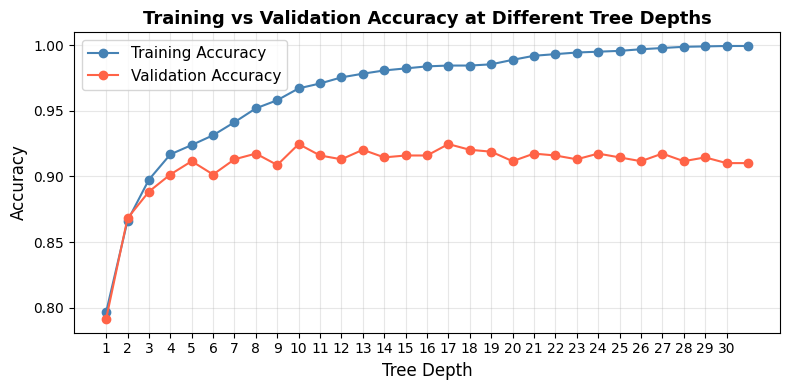

Best depth based on validation: 10 (validation accuracy: 92.46%)


In [13]:
# test depths from 1 to 32(The depth of the base model)
depths = range(1, 32)
train_scores = []
val_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    val_scores.append(model.score(X_val, y_val))

# plot
plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, 'o-', label='Training Accuracy', color='steelblue')
plt.plot(depths, val_scores, 'o-', label='Validation Accuracy', color='tomato')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs Validation Accuracy at Different Tree Depths', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(range(1, 31))
plt.tight_layout()
plt.show()

# find the best depth (highest validation accuracy)
best_depth = depths[np.argmax(val_scores)]
print(f"Best depth based on validation: {best_depth} (validation accuracy: {max(val_scores)*100:.2f}%)")

Based on the curves we determined that the optimal tree depth is 10. after that point the gap between the training score and validation score is increasing, Therefore, we have selected Depth 10 for fixing overfitting and we will continue to refine the model by testing other hyperparameters.

### 2.3 Tune other hyperparameters using validation set to fix overfitting
with `max_depth`, we also tune:
- **min_samples_split** — minimum number of samples needed to split a node
- **min_samples_leaf** — minimum number of samples in a leaf node
- **ccp_alpha** — cost complexity pruning parameter

**min_samples_split**

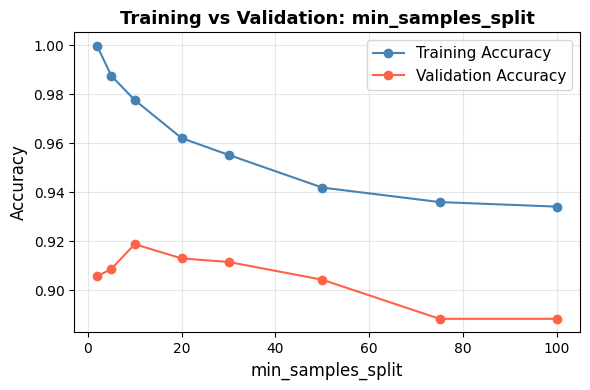

Best min_samples_split: 10 (validation accuracy: 91.88%)


In [14]:
# test different min_samples_split values
split_values = [2, 5, 10, 20, 30, 50, 75, 100]
train_scores_split = []
val_scores_split = []

for s in split_values:
    model = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    model.fit(X_train, y_train)
    train_scores_split.append(model.score(X_train, y_train))
    val_scores_split.append(model.score(X_val, y_val))

# plot
plt.figure(figsize=(6, 4))
plt.plot(split_values, train_scores_split, 'o-', label='Training Accuracy', color='steelblue')
plt.plot(split_values, val_scores_split, 'o-', label='Validation Accuracy', color='tomato')
plt.xlabel('min_samples_split', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs Validation: min_samples_split', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_split = split_values[np.argmax(val_scores_split)]
print(f"Best min_samples_split: {best_split} (validation accuracy: {max(val_scores_split)*100:.2f}%)")

Less than accuracy of max_depth=10, there is no improvement

**min_samples_leaf**

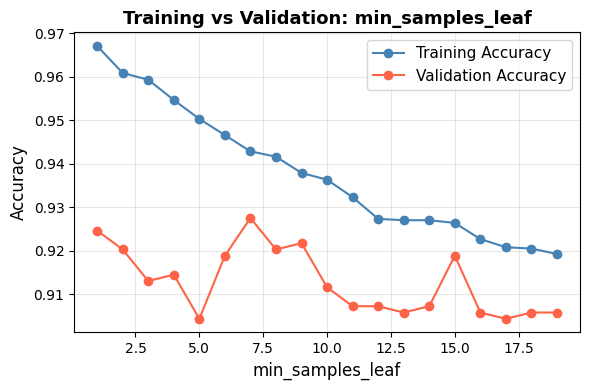

Best min_samples_leaf: 7 (validation accuracy: 92.75%)


In [15]:
# test different min_samples_leaf values with max_depth=10
leaf_samples = range(1, 20)
train_scores_leaf = []
val_scores_leaf = []

for l in leaf_samples:
    model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=l, random_state=42)
    model.fit(X_train, y_train)
    train_scores_leaf.append(model.score(X_train, y_train))
    val_scores_leaf.append(model.score(X_val, y_val))

# plot
plt.figure(figsize=(6, 4))
plt.plot(leaf_samples, train_scores_leaf, 'o-', label='Training Accuracy', color='steelblue')
plt.plot(leaf_samples, val_scores_leaf, 'o-', label='Validation Accuracy', color='tomato')
plt.xlabel('min_samples_leaf', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs Validation: min_samples_leaf', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_leaf = leaf_samples[np.argmax(val_scores_leaf)]
print(f"Best min_samples_leaf: {best_leaf} (validation accuracy: {max(val_scores_leaf)*100:.2f}%)")

The result (92.75%) better than previous models results (92.46%), So now this the best model with hyperbarameters max_depth=10, min_samples_leaf=7.

**ccp_alpha**

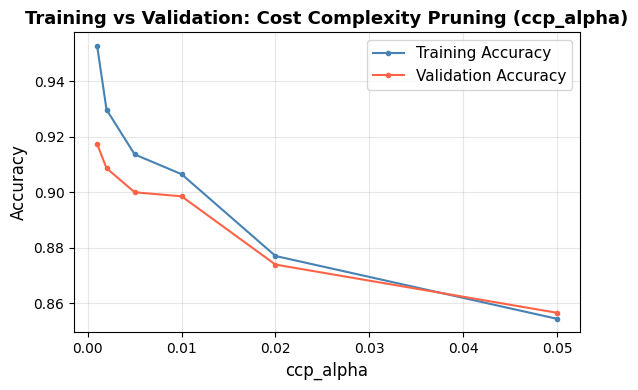

Best ccp_alpha: 0.001000 (validation accuracy: 91.74%)


In [16]:
ccp_alphas = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
train_scores_ccp = []
val_scores_ccp = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(max_depth=10, ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    train_scores_ccp.append(model.score(X_train, y_train))
    val_scores_ccp.append(model.score(X_val, y_val))

# plot
plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, train_scores_ccp, 'o-', label='Training Accuracy', color='steelblue', markersize=3)
plt.plot(ccp_alphas, val_scores_ccp, 'o-', label='Validation Accuracy', color='tomato', markersize=3)
plt.xlabel('ccp_alpha', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs Validation: Cost Complexity Pruning (ccp_alpha)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = ccp_alphas[np.argmax(val_scores_ccp)]
print(f"Best ccp_alpha: {best_alpha:.6f} (validation accuracy: {max(val_scores_ccp)*100:.2f}%)")

The result less than the best result.

**Now we will compine the best values on each hyperparameter and see if the result will improve?**

In [17]:
# Try to compaine the best value on the hyperparameters
model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=7, ccp_alpha=0.001000, random_state=42)
model.fit(X_train, y_train)
Val_acc = model.score(X_val, y_val)
print(f"validation Accuracy:{Val_acc*100:.2f}%")

validation Accuracy:91.88%


The result less than the best result.

After hyperparameters tuning, we identified that the optimal configuration for our Decision Tree to fix the overfitting is a max_depth of 10 and a min_samples_leaf of 7. This specific combination provides the best balance, achieving high validation accuracy while effectively controlling overfitting. Therefore, we have selected this configuration as our final optimized model to be compared with the base model.

### 2.4 Build the final pruned model

In [18]:
pruned_model = DecisionTreeClassifier( max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42)
pruned_model.fit(X_train, y_train)

# predict on test set
pred_pruned = pruned_model.predict(X_test)
acc_pruned = accuracy_score(y_test, pred_pruned)
cm_pruned = confusion_matrix(y_test, pred_pruned)

# compare base vs pruned
print("=== Base Model (Overfitting) ===")
print(f"Training Accuracy:   {train_acc_base*100:.2f}%")
print(f"Test Accuracy:       {test_acc_base*100:.2f}%")
print(f"Tree Depth:          {b_model.get_depth()}")
print(f"Number of Leaves:    {b_model.get_n_leaves()}")
print()
print("=== Pruned Model (Overfitting Fixed) ===")
print(f"Training Accuracy:   {pruned_model.score(X_train, y_train)*100:.2f}%")
print(f"Test Accuracy:       {acc_pruned*100:.2f}%")
print(f"Tree Depth:          {pruned_model.get_depth()}")
print(f"Number of Leaves:    {pruned_model.get_n_leaves()}")

=== Base Model (Overfitting) ===
,Training Accuracy:   99.97%
,Test Accuracy:       87.84%
,Tree Depth:          32
,Number of Leaves:    214
,
,=== Pruned Model (Overfitting Fixed) ===
,Training Accuracy:   94.29%
,Test Accuracy:       90.16%
,Tree Depth:          10
,Number of Leaves:    70


### 2.5 Confusion matrix  Base vs Pruned

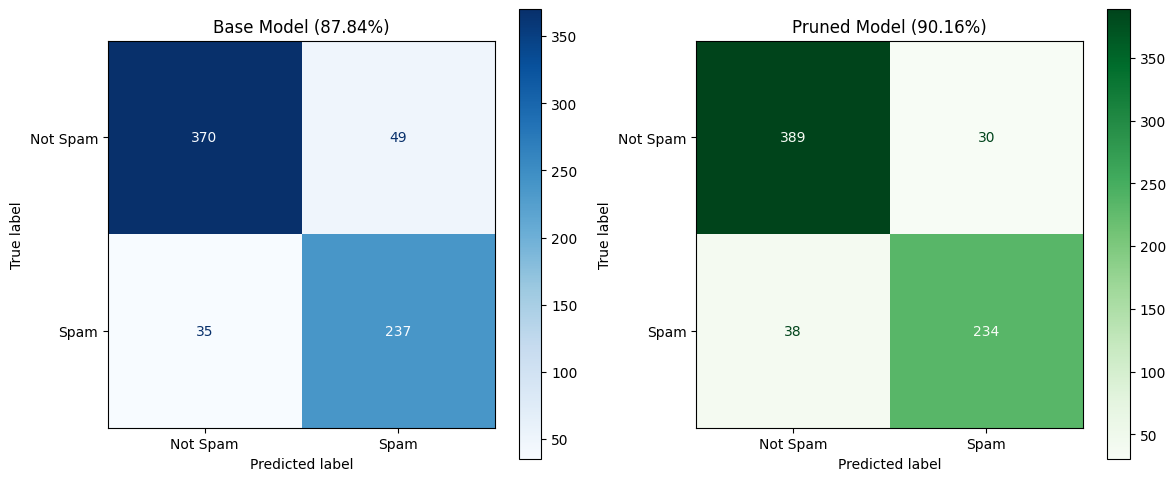

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Base Model ({b_acc*100:.2f}%)')
ConfusionMatrixDisplay(cm_pruned, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Pruned Model ({acc_pruned*100:.2f}%)')
plt.tight_layout()
plt.show()

### Discussion

The base model (no pruning) achieved near to 100% training accuracy but much lower test accuracy. This large gap is a sign of overfitting — the tree memorized the training data instead of learning general patterns.

By tuning hyperparameters using the validation set, we found the best combination of max_depth and min_samples_leaf. The pruned model has:
- A smaller, simpler tree (fewer leaves and lower depth)
- Lower training accuracy.
- Higher test accuracy.

This confirms that pruning successfully addressed the overfitting problem.

---
---
# Case 3: Bias / Imbalanced Dataset (With vs Without)

The dataset is imbalanced — 60.6% Not Spam vs 39.4% Spam. This means the model might be biased toward predicting Not Spam more often simply because it has seen more of those examples during training.

We test and compare THREE methods to fix this imbalance:
  1. Random Undersampling  — removes majority class (Not Spam) samples
  2. Random Oversampling   — duplicates existing minority class (Spam) samples
  3. SMOTE                 — generates NEW synthetic Spam samples (best practice)

 All methods are applied to the TRAINING set only.
 The test set and validation set are NEVER modified.


In [20]:

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import recall_score, precision_score, f1_score

### 3.1: Show the class imbalance

In [21]:
print("=== Training Set BEFORE Balancing ===")
print(f"Not Spam: {(y_train == 0).sum()} emails ({(y_train == 0).mean()*100:.1f}%)")
print(f"Spam:     {(y_train == 1).sum()} emails ({(y_train == 1).mean()*100:.1f}%)")

=== Training Set BEFORE Balancing ===
,Not Spam: 1951 emails (60.6%)
,Spam:     1269 emails (39.4%)


### 3.2: Apply all three balancing methods

In [22]:
# Method 1: Random Undersampling
# Randomly REMOVES Not Spam emails until both classes are equal.
# Downside: we lose useful training data.
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print("=== After Random Undersampling ===")
print(f"Not Spam: {(y_train_under == 0).sum()} | Spam: {(y_train_under == 1).sum()}")
print(f"Size: {len(X_train)} → {len(X_train_under)}  (removed {len(X_train) - len(X_train_under)} Not Spam emails)")
print()

# Method 2: Random Oversampling
# Randomly DUPLICATES existing Spam emails until both classes are equal.
# Downside: repeating exact copies can cause overfitting.
oversampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

print("=== After Random Oversampling ===")
print(f"Not Spam: {(y_train_over == 0).sum()} | Spam: {(y_train_over == 1).sum()}")
print(f"Size: {len(X_train)} → {len(X_train_over)}  (added {len(X_train_over) - len(X_train)} duplicate Spam emails)")
print()

# Method 3: SMOTE
# GENERATES new synthetic Spam emails instead of duplicating existing ones.
# How it works:
#   1. Takes a Spam email
#   2. Finds its K nearest neighbors (other Spam emails)
#   3. Creates a new synthetic email at a random point between them
# Best method: no data loss, no exact duplicates.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== After SMOTE ===")
print(f"Not Spam: {(y_train_smote == 0).sum()} | Spam: {(y_train_smote == 1).sum()}")
print(f"Size: {len(X_train)} → {len(X_train_smote)}  (added {len(X_train_smote) - len(X_train)} synthetic Spam emails)")

=== After Random Undersampling ===
,Not Spam: 1269 | Spam: 1269
,Size: 3220 → 2538  (removed 682 Not Spam emails)
,
,=== After Random Oversampling ===
,Not Spam: 1951 | Spam: 1951
,Size: 3220 → 3902  (added 682 duplicate Spam emails)
,
,=== After SMOTE ===
,Not Spam: 1951 | Spam: 1951
,Size: 3220 → 3902  (added 682 synthetic Spam emails)


### Step 3.3: Train a Decision Tree for Each Balancing Method

We train a separate Decision Tree for each balancing method using the modified
training set, then evaluate all models on the same unmodified test set.
This guarantees a fair comparison across all four models.

We focus on **Accuracy** and **Recall (Spam)** as our primary metrics.

> Note: Test set is always the same (X_test, y_test) — never modified.

In [23]:
# Base model (no balancing)
print("=== Base Model (No Balancing) ===")
print(f"Accuracy : {b_acc*100:.2f}%")
print(f"Recall   : {recall_score(y_test, b_pred, pos_label=1):.2f}")
print()

# Undersampling model
model_under = DecisionTreeClassifier(random_state=42)
model_under.fit(X_train_under, y_train_under)
pred_under = model_under.predict(X_test)
acc_under  = accuracy_score(y_test, pred_under)
cm_under   = confusion_matrix(y_test, pred_under)

print("=== Undersampling ===")
print(f"Accuracy : {acc_under*100:.2f}%")
print(f"Recall   : {recall_score(y_test, pred_under, pos_label=1):.2f}")
print()

# Random Oversampling model
model_over = DecisionTreeClassifier(random_state=42)
model_over.fit(X_train_over, y_train_over)
pred_over = model_over.predict(X_test)
acc_over  = accuracy_score(y_test, pred_over)
cm_over   = confusion_matrix(y_test, pred_over)

print("=== Random Oversampling ===")
print(f"Accuracy : {acc_over*100:.2f}%")
print(f"Recall   : {recall_score(y_test, pred_over, pos_label=1):.2f}")
print()

# SMOTE model
model_smote = DecisionTreeClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
pred_smote = model_smote.predict(X_test)
acc_smote  = accuracy_score(y_test, pred_smote)
cm_smote   = confusion_matrix(y_test, pred_smote)

print("=== SMOTE ===")
print(f"Accuracy : {acc_smote*100:.2f}%")
print(f"Recall   : {recall_score(y_test, pred_smote, pos_label=1):.2f}")

=== Base Model (No Balancing) ===
,Accuracy : 87.84%
,Recall   : 0.87
,
,=== Undersampling ===
,Accuracy : 90.01%
,Recall   : 0.90
,
,=== Random Oversampling ===
,Accuracy : 89.73%
,Recall   : 0.89
,
,=== SMOTE ===
,Accuracy : 93.49%
,Recall   : 0.93


### 3.4: Confusion Matrices for Base Model vs Each Balancing Method
We compare the Base Model against each balancing method separately.


#### 3.4.1: Undersampling

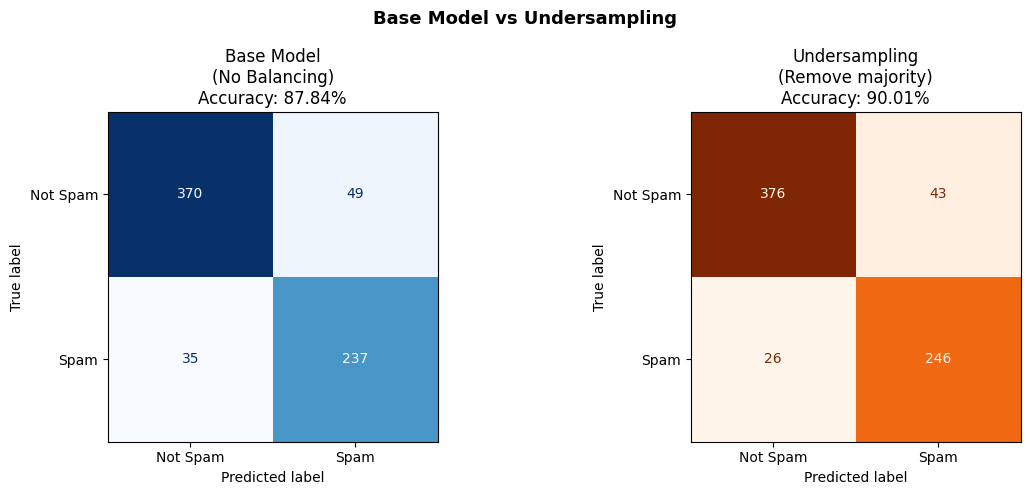

In [24]:
# Base vs Undersampling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Base Model\n(No Balancing)\nAccuracy: {b_acc*100:.2f}%')
ConfusionMatrixDisplay(cm_under, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'Undersampling\n(Remove majority)\nAccuracy: {acc_under*100:.2f}%')
plt.suptitle('Base Model vs Undersampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.4.2: Oversampling

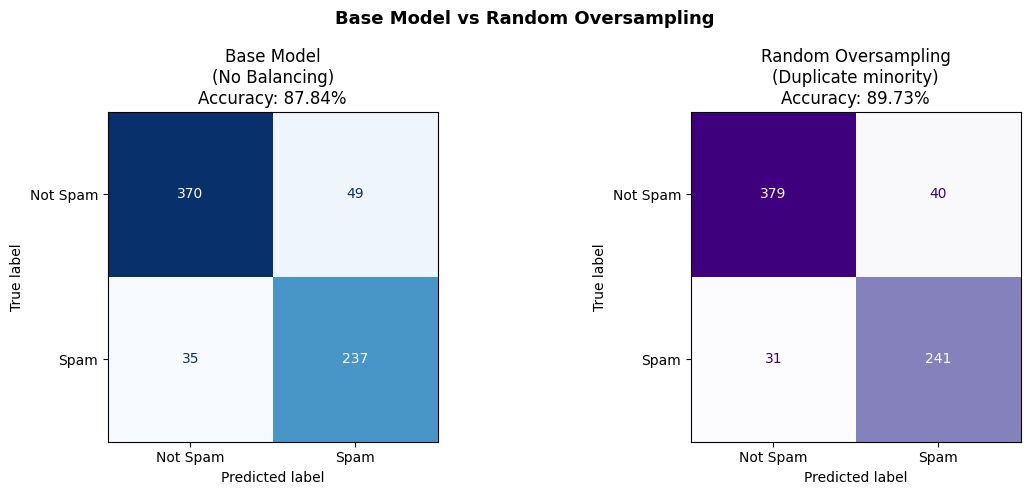

In [25]:
# Base vs Random Oversampling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Base Model\n(No Balancing)\nAccuracy: {b_acc*100:.2f}%')
ConfusionMatrixDisplay(cm_over, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title(f'Random Oversampling\n(Duplicate minority)\nAccuracy: {acc_over*100:.2f}%')
plt.suptitle('Base Model vs Random Oversampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.4.3: SMOTE

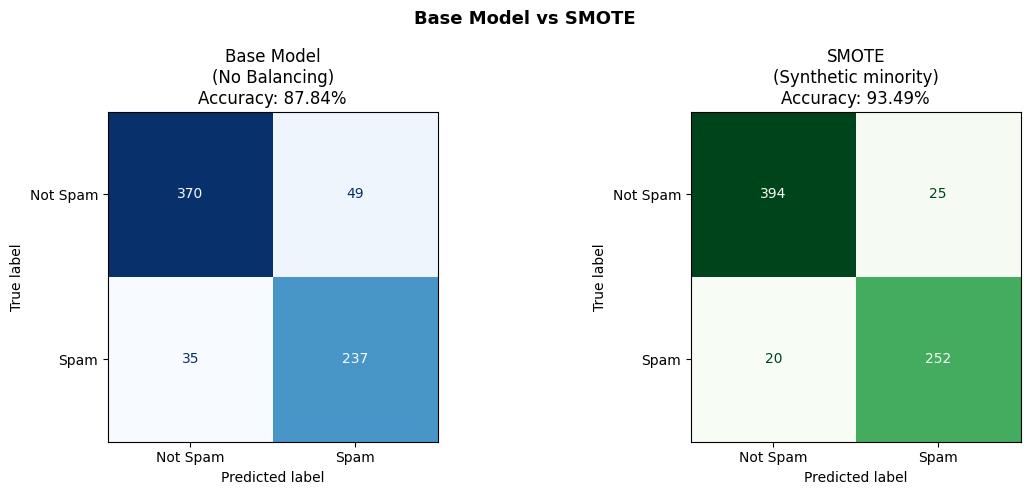

In [26]:
# Base vs SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(b_matrix, display_labels=['Not Spam','Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Base Model\n(No Balancing)\nAccuracy: {b_acc*100:.2f}%')
ConfusionMatrixDisplay(cm_smote, display_labels=['Not Spam','Spam']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'SMOTE\n(Synthetic minority)\nAccuracy: {acc_smote*100:.2f}%')
plt.suptitle('Base Model vs SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5: Bar Chart To Compare Between Accuracy and Recall


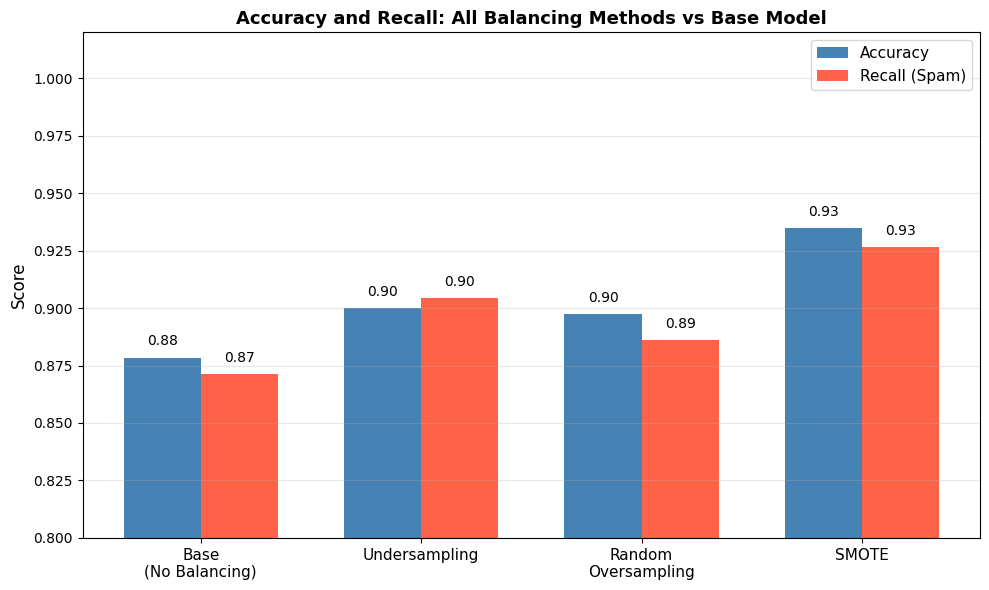

In [27]:
methods    = ['Base\n(No Balancing)', 'Undersampling', 'Random\nOversampling', 'SMOTE']
accuracies = [b_acc,     acc_under,    acc_over,    acc_smote]
recalls    = [recall_score(y_test, b_pred,    pos_label=1),
              recall_score(y_test, pred_under, pos_label=1),
              recall_score(y_test, pred_over,  pos_label=1),
              recall_score(y_test, pred_smote, pos_label=1)]

x     = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',      color='steelblue')
bars2 = ax.bar(x + width/2, recalls,    width, label='Recall (Spam)', color='tomato')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0.80, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Accuracy and Recall: All Balancing Methods vs Base Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion

The Base Model scored **0.88** Accuracy and **0.87** Recall on the Spam class —
the weakest results due to the class imbalance in the training data.

**Random Undersampling** improved both metrics (Accuracy: **0.90**, Recall: **0.90**).
However, the improvement is limited because removing training data means the model
has less information to learn from overall.

**Random Oversampling** produced similar but slightly weaker results (Accuracy: **0.90**,
Recall: **0.89**), confirming that duplicating exact copies does not add useful
new information for the model to learn from.

**SMOTE** achieved the best results (Accuracy: **0.93**, Recall: **0.93**),
improving both metrics by the largest margin. By generating diverse synthetic
spam examples, the model learned better spam patterns without losing any data
and without repeating exact copies.

SMOTE is the best choice — highest spam
detection rate (Recall: **0.93**), meaning it catches the most spam
emails out of all methods.

---
## Final Model Comparison: SMOTE vs Pruned

We compare the two best models from all cases. Normalization is excluded
since all three methods produced results identical or near-identical to
the base model, confirming that normalization does not impact Decision Trees.


In [28]:

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall (Spam)', 'Precision (Spam)', 'F1-Score (Spam)', 'Tree Depth', 'Leaves'],
    'SMOTE Model': [
        f"{acc_smote*100:.2f}%",
        f"{recall_score(y_test, pred_smote, pos_label=1):.2f}",
        f"{precision_score(y_test, pred_smote, pos_label=1):.2f}",
        f"{f1_score(y_test, pred_smote, pos_label=1):.2f}",
        str(model_smote.get_depth()),
        str(model_smote.get_n_leaves())
    ],
    'Pruned Model': [
        f"{acc_pruned*100:.2f}%",
        f"{recall_score(y_test, pred_pruned, pos_label=1):.2f}",
        f"{precision_score(y_test, pred_pruned, pos_label=1):.2f}",
        f"{f1_score(y_test, pred_pruned, pos_label=1):.2f}",
        str(pruned_model.get_depth()),
        str(pruned_model.get_n_leaves())
    ]
})
print(comparison.to_string(index=False))

          Metric SMOTE Model Pruned Model
,        Accuracy      93.49%       90.16%
,   Recall (Spam)        0.93         0.86
,Precision (Spam)        0.91         0.89
, F1-Score (Spam)        0.92         0.87
,      Tree Depth          28           10
,          Leaves         239           70


---
## Discussion

SMOTE outperforms the pruned model across all metrics. Most critically,
SMOTE achieves a Recall of 0.93 vs 0.86 for the pruned model on the Spam class.
Recall is the most important metric here is recall, a low recall means dangerous spam
emails slip through undetected.

Although the pruned model has a cleaner tree structure having depth 10, 70 leaves
and generalizes better by avoiding overfitting, its lower recall makes it
less suitable for spam detection specifically.

Therefore, SMOTE is selected as the best model. A potential future improvement
would be combining both techniques applying SMOTE to balance the data and
pruning the tree which could give both high recall and a cleaner structure.


---
# Decision Tree Visualization & Rules

The best performing model is the SMOTE.
We use this model for the final tree visualization and rules.

The decision tree is visualized and rules are printed at depth 3 to maintain
readability. The full SMOTE tree has depth 28 with 239 leaves displaying
all rules would produce hundreds of conditions impractical to interpret.
Truncated branches indicate the tree continues deeper beyond the displayed levels.

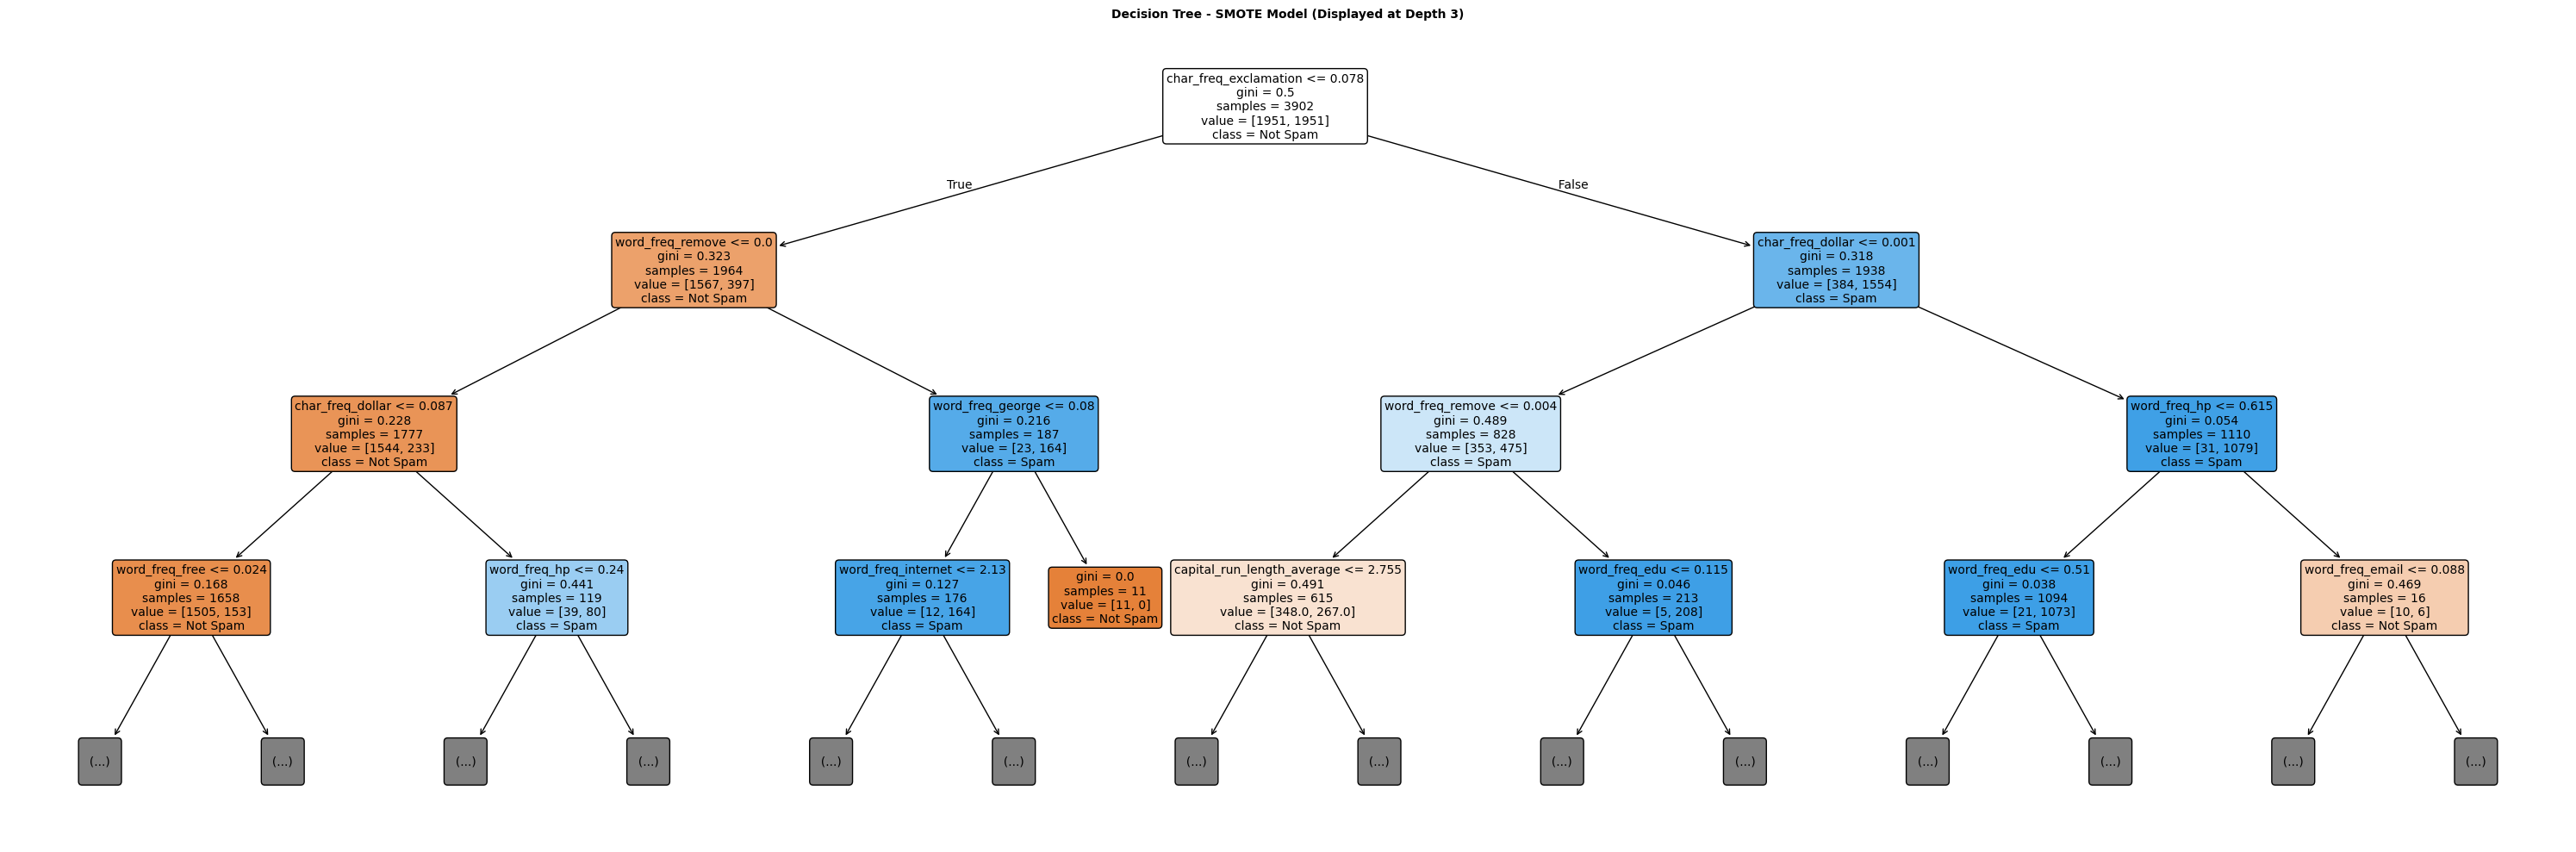

In [29]:
# visualize the SMOTE model tree limited to depth 3 for readability
plt.figure(figsize=(30, 10))
plot_tree(
    model_smote,
    max_depth=3,
    filled=True,
    feature_names=list(X_train.columns),
    class_names=['Not Spam', 'Spam'],
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree - SMOTE Model (Displayed at Depth 3)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Observations on tree:**

Orange nodes represent Not Spam predictions, blue nodes represent Spam predictions.
Nodes showing (...) means the tree continues deeper but is hidden for readability.

In [30]:
# print the decision tree rules limited to depth 3
rules = export_text(  model_smote, feature_names=list(X_train.columns), max_depth=3)

print("___ Decision Tree Rules ___")
print(rules)

___ Decision Tree Rules ___
,|--- char_freq_exclamation <= 0.08
,|   |--- word_freq_remove <= 0.00
,|   |   |--- char_freq_dollar <= 0.09
,|   |   |   |--- word_freq_free <= 0.02
,|   |   |   |   |--- truncated branch of depth 25
,|   |   |   |--- word_freq_free >  0.02
,|   |   |   |   |--- truncated branch of depth 10
,|   |   |--- char_freq_dollar >  0.09
,|   |   |   |--- word_freq_hp <= 0.24
,|   |   |   |   |--- truncated branch of depth 9
,|   |   |   |--- word_freq_hp >  0.24
,|   |   |   |   |--- class: 0
,|   |--- word_freq_remove >  0.00
,|   |   |--- word_freq_george <= 0.08
,|   |   |   |--- word_freq_internet <= 2.13
,|   |   |   |   |--- truncated branch of depth 9
,|   |   |   |--- word_freq_internet >  2.13
,|   |   |   |   |--- class: 0
,|   |   |--- word_freq_george >  0.08
,|   |   |   |--- class: 0
,|--- char_freq_exclamation >  0.08
,|   |--- char_freq_dollar <= 0.00
,|   |   |--- word_freq_remove <= 0.00
,|   |   |   |--- capital_run_length_average <= 2.75
,|   |

**Key Observations from the Rules:**
- The first and most important split is on char_freq_exclamation (! frequency)
- Low ! AND word_freq_remove present → likely Not Spam
- High ! AND high char_freq_dollar → likely Spam
- This makes intuitive sense — spam emails commonly use excessive
  exclamation marks and dollar signs to grab attention.

---
## Conclusion

This project implemented a Decision Tree classifier to detect spam emails
using the Spambase dataset. Three cases were studied:

- **Normalization** had minimal impact on the Decision Tree as expected,
  since trees split on thresholds not distances.
- **Pruning** successfully reduced overfitting, improving test accuracy
  from 87.84% to 90.16% with a much cleaner tree structure.
- **SMOTE** produced the best overall results (93.49% accuracy, 0.93 recall),
  significantly improving spam detection by addressing class imbalance.

The best model is SMOTE. A future improvement would be combining SMOTE
with pruning to achieve both high accuracy and a cleaner tree structure.